In [ ]:
""" Comentário pós aula
Bagging = Bootstrap Aggregating

Métodos de ENSEMBLE: Média e Boosting

Métodos de média (Random Forest)
- Constroem diversos estimadores e tira sua média
- Reduz a variância

Métodos de Boosting (AdaBoost)
- Constroem estimadores de forma esquencial
- Tenta reduzir o viés conjunto

Bagging = Bootstrapping + Aggregation

Bootstrapping - gera várias árvores independentes
Aggregation - agrega as decisões de várias árvores

- Em classificação = classe final é a classe majoritária
- Em regressão = valor final é a média dos valores de cada árvore

Parâmetros:
n_estimators - quantas árvores independentes serão construídas
max_features - número de features a serem utilizadas em cada quebra

#DIFERENÇA - COMO RETIRAR O OVERFITTING: 
rf = RandomForestClassifier(random_state = 42, n_estimators = 100, max_depth = 3)

# Definir o máximo de estimadores (n_estimators = 100)
# Definir a profundidade máxima (max_depth = 3)
"""

# Aula 8 - Métodos de Ensemble: Bagging e Random Forest

_________________

## 1) Métodos de Ensemble: recordando


Os chamados **métodos de ensemble**, que tem como objetivo **combinar as predições de diversos estimadores mais simples** para gerar uma **predição final mais robusta**

Os métodos de ensemble costuman ser divididos em duas classes:

- **Métodos de média**: têm como procedimento geral construir diversos estimadores independentes, e tomar a média de suas predições como a predição final. O principal objetivo do método é reduzir **variância**, de modo que o modelo final seja melhor que todos os modelos individuais. Ex.: **random forest.**
<br>

- **Métodos de boosting**: têm como procedimento geral a construção de estimadores de forma sequencial, de modo que estimadores posteriores tentam reduzir o **viés** do estimador conjunto, que leva em consideração estimadores anteriores. Ex.: **adaboost**.

Na aula de hoje, vamos conhecer em detalhes os procedimentos de bagging, explorando, particularmente, a **random forest**.

In [ ]:
"""Métodos de ENSEMBLE: Média e Boosting

Métodos de média (Random Forest)
- Constroem diversos estimadores e tira sua média
- Reduz a variância

Métodos de Boosting (AdaBoost)
- Constroem estimadores de forma esquencial
- Tenta reduzir o viés conjunto
"""

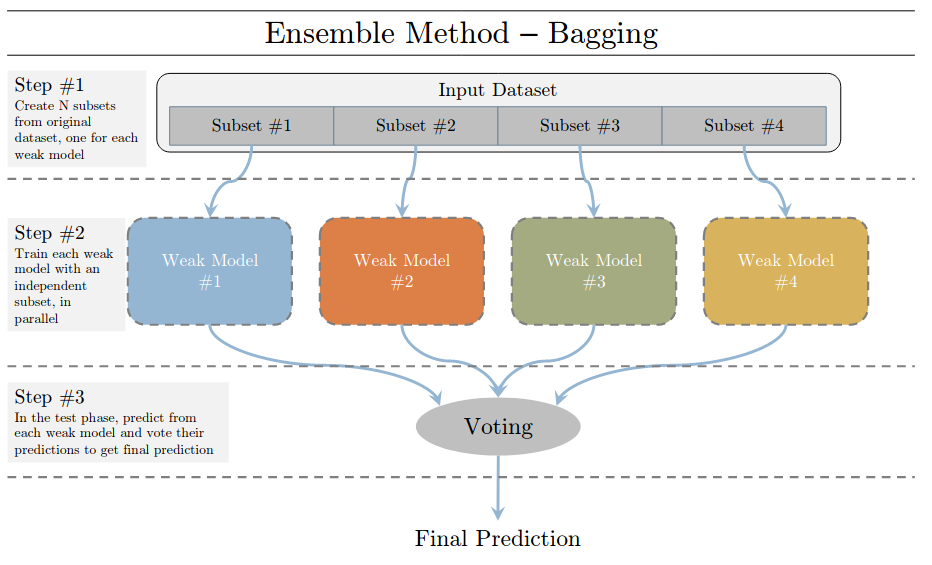<img src='images/bagging.png' style="width:900px"  text="http://cheatsheets.aqeel-anwar.com" />  

_________
_______
_________

## 2) Bagging & Random Forest

Uma técnica muito interessante (e muito performática!) baseada em árvores é o **Random Forest**.

Neste método, são criadas varias **árvores diferentes e independentes entre si**, através de um processo **aleatório**, e a predição final é tomada através da média das predições individuais!

<img src="https://i.ytimg.com/vi/goPiwckWE9M/maxresdefault.jpg" width=700>

O Random Forest utiliza os conceitos de **bootstrapping** e **aggregation** (ou então, o procedimento composto **bagging**) para criar um modelo composto que é melhor que uma única árvore!

<img src="https://c.mql5.com/2/33/image1__1.png" width=600>

Vamos entrender um pouco melhor cada componente do método!

### Bootstrapping

O procedimento de **bootstrapping** é utilizado no contexto do random forest para gerar os chamados **bootstrapped datasets**.

A ideia é bem simples! Para a criação de cada bootstrapped dataset, primeiro:

> Selecionamos **aleatoriamente com reposição** algumas linhas da base original. Isso gera um novo dataset (reamostrado), chamado de **bootstrapped dataset**. O número de linhas do dataset reamostrado é controlável.

Logo após, fazemos uma árvore de decisão **treinada neste dataset reamostrado**. Mas com um detalhe:

> Usamos apenas um **subconjunto aleatório das features** em cada avaliação de quebras (isso equivale ao `splitter="random"`). A quantidade de features a serem consideradas é controlável.

Com isso, muitas árvores são geradas (a quantidade também é controlável), cada uma seguindo o procedimento de bootstrap!

Note que o o procedimento de bootstrapping introduz **duas fontes de aleatoriedade**, cujo objetivo é **diminuir a variância** (tendência a overfitting) do modelo.

De fato, árvores individuais são facilmente overfitadas, como discutimos em aula (lembre-se da grande flexibilidade da hipótese em encontrar condições favoráveis à aprendizagem dos ruídos!).

Com esta aleatorização introduzida pelo bootstrapping, o objetivo é que as árvores construídas sejam **independentes**, de modo que **os erros cometidos por cada uma sejam independentes**. 

Deste modo, se considerarmos as previsões isoladas e de alguma forma **agregar** as previsões, a expectativa é que o modelo final seja **menos propenso a overfitting**! Mas, uma pergunta natural é: o que é essa "agragação"? Aqui entra o segundo elemento do bagging...

### Aggregation

Entendemos como o bootstrap é utilizado para gerar várias árvores independentes. 

Então, quando temos uma nova observação para atribuir o target, passamos as features **por cada uma das árvores**, e, naturalmente, cada árvore produz **o seu target**, que pode muito bem não ser o mesmo!

A **agregação** é utilizada para tomar a decisão final:

> No caso de classificação, a classe final é atribuída como **a classe majoritária**, isso é, **a classe que foi o output $\hat{y}$ mais vezes dentre todas as árvores**;

> No caso de regressão, o valor final é atribuído como **a média dos valores preditos $\hat{y}$ por cada árvore**.

Note que em ambos os casos, o procedimento de agregação pode ser visto como uma **média**, e o sklearn deixa isso explícito: "*In contrast to the original publication, the scikit-learn implementation combines classifiers by averaging their probabilistic prediction, instead of letting each classifier vote for a single class.*"

Tomando a média como procedimento de agregação, a expectativa é que **alguns erros sejam anulados**, garantindo uma previsão final **mais estável e mais generalizável**, dado que os ruídos são eliminados.

Juntando o bootstrapping com o aggregation, temos então o...

In [ ]:
""" Bagging = Bootstrapping + Aggregation

Bootstrapping - gera várias árvores independentes
Aggregation - agrega as decisões de várias árvores

- Em classificação = classe final é a classe majoritária
- Em regressão = valor final é a média dos valores de cada árvore
"""

### Bagging

> Bagging: **b**ootstrap **agg**regat**ing**

Esquematicamente:

<img src=https://media.geeksforgeeks.org/wp-content/uploads/20210707140912/Bagging.png width=500>

As classes do random forest são:

- [RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#sklearn.ensemble.RandomForestClassifier)

- [RandomForestRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html#sklearn.ensemble.RandomForestRegressor)

Ambos os métodos têm hiperparâmetros similares aos hiperparâmetros das árvores convencionais, aplicados a cada uma das árvores independentes.

Além destes, há dois hiperparâmetros bem importantes, referentes ao método de ensemble em si:

- `n_estimators` : controla quantas árvores independentes serão construídas (i.e., o número de árvores na floresta). Em geral, quanto mais árvores melhor (mas mais tempo vai demorar). Além disso, depois de uma determinade quantidade de árvores, os resultados vão parar de melhorar, pois há um limite para o bootstrap: depois de uma certa quantidade, as árvores deixam de ser tão independentes assim...
<br>

- `max_features`: o número de features no subconjunto aleatório de candidata a serem utilizadas em cada quebra. Quanto menor for o valor, mais conseguimos reduzir o overfitting, mas o underfitting é favorecido. Uma boa heurística é `max_features=None` para regressão e `max_features="sqrt"`para classificação, embora estratégias diferentes podem (e devem) ser testadas com o CV.


In [ ]:
"""Parâmetros:
n_estimators - quantas árvores independentes serão construídas
max_features - número de features a serem utilizadas em cada quebra
"""

_____________

Agora, veremos uma aplicação prática da Random Forest!

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer 
#SimpleImputer faz tratamento de valores nulos

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

#### Divisão dos dados em treinamento e teste

In [4]:
df = pd.read_csv("datasets/german_credit_data.csv", index_col = 0)

# Separação entre features e target
X = df.drop(columns = "Risk")
y = df["Risk"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42, stratify = y)

In [5]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [6]:
X_train.shape

(750, 9)

In [7]:
X_test.shape

(250, 9)

#### Tratamento de dados

Uma vez mais, vamos enfocar, por enquanto, apenas os dados numéricos.

In [11]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 750 entries, 123 to 744
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               750 non-null    int64 
 1   Sex               750 non-null    object
 2   Job               750 non-null    int64 
 3   Housing           750 non-null    object
 4   Saving accounts   614 non-null    object
 5   Checking account  449 non-null    object
 6   Credit amount     750 non-null    int64 
 7   Duration          750 non-null    int64 
 8   Purpose           750 non-null    object
dtypes: int64(4), object(5)
memory usage: 58.6+ KB


Vamos assumir que preencheremos valores nulos, nas colunas numéricas, com a média. Podemos utilizar o [SimpleImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html) para fazê-lo!

In [12]:
# O SimpleImputer segue a mesma lógica de outros "transformers" que estudamos, 
# como os de normalização/padronização
sim_imp = SimpleImputer(strategy = "mean").fit(X_train.select_dtypes(include = np.number))
# Pedir pro simple imputer fitar (ajustar) os dados de treino (só numéricos)

X_train = sim_imp.transform(X_train.select_dtypes(include = np.number))
#passar o transform nos dados de treino
X_test = sim_imp.transform(X_test.select_dtypes(include = np.number))
#passar o transform nos dados de teste

# Scaling dos dados (após tratar os valores nulos)
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train_num)
X_test = scaler.transform(X_test_num)

In [13]:
# Não temos mais os valores nulos
np.isnan(X_train).sum()
#np.isnan = verifica se há algum valor que é um NaN

0

#### Treinamento e avaliação do modelo

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

==== Avaliação no conjunto de treinamento ====


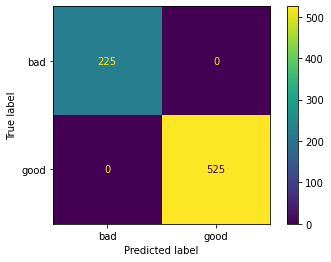

              precision    recall  f1-score   support

         bad       1.00      1.00      1.00       225
        good       1.00      1.00      1.00       525

    accuracy                           1.00       750
   macro avg       1.00      1.00      1.00       750
weighted avg       1.00      1.00      1.00       750


==== Avaliação no conjunto de teste ====


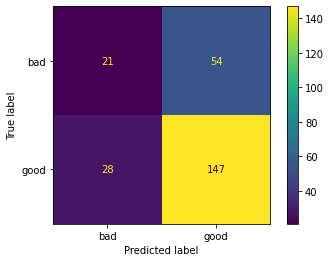

              precision    recall  f1-score   support

         bad       0.43      0.28      0.34        75
        good       0.73      0.84      0.78       175

    accuracy                           0.67       250
   macro avg       0.58      0.56      0.56       250
weighted avg       0.64      0.67      0.65       250



In [17]:
# Iniciamos o modelo
rf = RandomForestClassifier(random_state = 42)

# Treinamento do modelo
rf.fit(X_train, y_train)

# Avaliação no conjunto de treinamento
print("==== Avaliação no conjunto de treinamento ====")
y_pred_train = rf.predict(X_train)
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train)
plt.show()
print(classification_report(y_train, y_pred_train))

print("\n==== Avaliação no conjunto de teste ====")
y_pred_test = rf.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test)
plt.show()
print(classification_report(y_test, y_pred_test))

___

Parece que temos fortes indicativos de um **overfitting** (sobreajuste) dos dados anteriores, não é mesmo? Podemos perceber isso pelo erro nulo no conjunto de treinamento, e queda considerável de performance nos dados de teste. 

Como poderíamos tentar resolver esse problema?

==== Avaliação no conjunto de treinamento ====


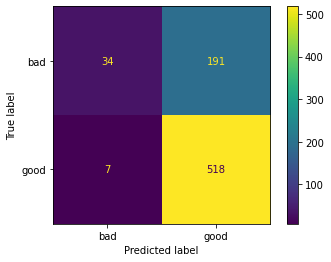

              precision    recall  f1-score   support

         bad       0.83      0.15      0.26       225
        good       0.73      0.99      0.84       525

    accuracy                           0.74       750
   macro avg       0.78      0.57      0.55       750
weighted avg       0.76      0.74      0.66       750


==== Avaliação no conjunto de teste ====


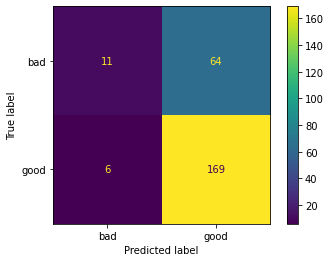

              precision    recall  f1-score   support

         bad       0.65      0.15      0.24        75
        good       0.73      0.97      0.83       175

    accuracy                           0.72       250
   macro avg       0.69      0.56      0.53       250
weighted avg       0.70      0.72      0.65       250



In [18]:
# Iniciamos o modelo
rf = RandomForestClassifier(random_state = 42, n_estimators = 100, max_depth = 3)
#DIFERENÇA - COMO RETIRAR O OVERFITTING: 
# Definir o máximo de estimadores (n_estimators = 100)
# Definir a profundidade máxima (max_depth = 3)

# Treinamento do modelo
rf.fit(X_train, y_train) #fitar o modelo

# Avaliação no conjunto de treinamento
print("==== Avaliação no conjunto de treinamento ====")
y_pred_train = rf.predict(X_train)
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train)
plt.show()
print(classification_report(y_train, y_pred_train))

print("\n==== Avaliação no conjunto de teste ====")
y_pred_test = rf.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test)
plt.show()
print(classification_report(y_test, y_pred_test))

Note que, ao alterarmos a profundidade da árvore para **3**, tivemos uma piora da performance nos dados de treinamento, mas a perda em capacidade de generalização, conforme medida pela discrepância de performance nos conjuntos de dados de treinamento e teste, foi bem menor! Isso fornece indicativos de que o modelo não está mais sobreajustado!

Fizemos apenas um "chute" para a escolha de parâmetros. Mais uma vez, é importante salientar a escolha de bons hiperparâmetros para os modelos.
___